<a href="https://colab.research.google.com/github/saifulroni/clusters_data/blob/main/clustering_fraud_trans_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Large_Scale_Implementation_of_DSK_Chain/refs/heads/main/Cleaned_Data/fraud_trans_dataset.csv'
df = pd.read_csv(url)
df.head()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour,Address Match,Customer Location Encoded,Payment Method_PayPal,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Product Category_clothing,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_desktop,Device Used_mobile,Device Used_tablet
0,42.32,1,40,0,282,23,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,301.34,3,35,0,223,0,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,340.32,5,29,0,360,8,0,5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,95.77,5,45,0,325,20,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,77.45,5,42,0,116,15,1,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
X = df.drop(columns=['Is Fraudulent'])
y = df['Is Fraudulent']

X_0 = X[y == 0]
X_1 = X[y == 1]

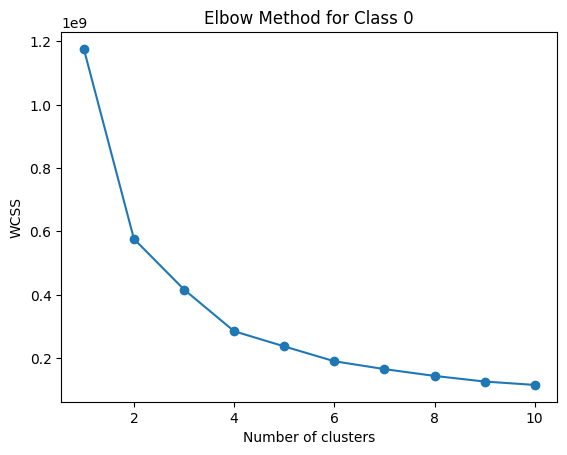

In [ ]:
wcss_0 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_0)
    wcss_0.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_0, marker='o')
plt.title('Elbow Method for Class 0')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

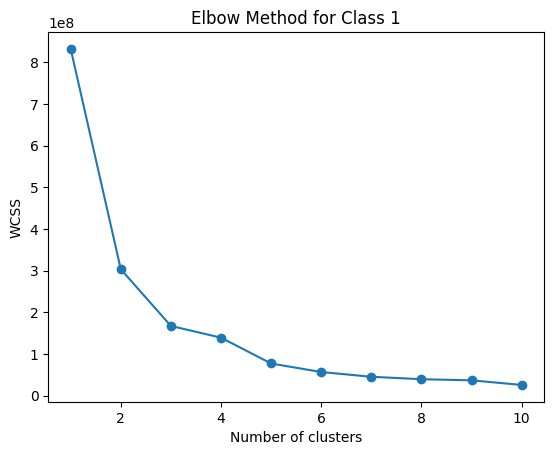

In [ ]:
wcss_1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_1)
    wcss_1.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_1, marker='o')
plt.title('Elbow Method for Class 1')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
n_clusters_0 = 2   # <-- set based on elbow visualization
n_clusters_1 = 3   # <-- set based on elbow visualization

kmeans_0 = KMeans(n_clusters=n_clusters_0, random_state=42, n_init=10)
sub_labels_0 = kmeans_0.fit_predict(X_0)

kmeans_1 = KMeans(n_clusters=n_clusters_1, random_state=42, n_init=10)
sub_labels_1 = kmeans_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 17886 samples
Class 0 - Cluster 1: 4526 samples


In [ ]:
counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 1 - Cluster 0: 184 samples
Class 1 - Cluster 1: 1013 samples
Class 1 - Cluster 2: 25 samples


DBSCAN

In [ ]:
dbscan_0 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_0 = dbscan_0.fit_predict(X_0)

dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_1 = dbscan_1.fit_predict(X_1)

In [ ]:
unique_0, counts_0 = np.unique(sub_labels_0, return_counts=True)
for cluster, count in zip(unique_0, counts_0):
    print(f"Class 0 - Cluster {cluster}: {count} samples")

Class 0 - Cluster -1: 22412 samples


In [ ]:
unique_1, counts_1 = np.unique(sub_labels_1, return_counts=True)
for cluster, count in zip(unique_1, counts_1):
    print(f"Class 1 - Cluster {cluster}: {count} samples")

Class 1 - Cluster -1: 1222 samples


Hierarchical Clustering

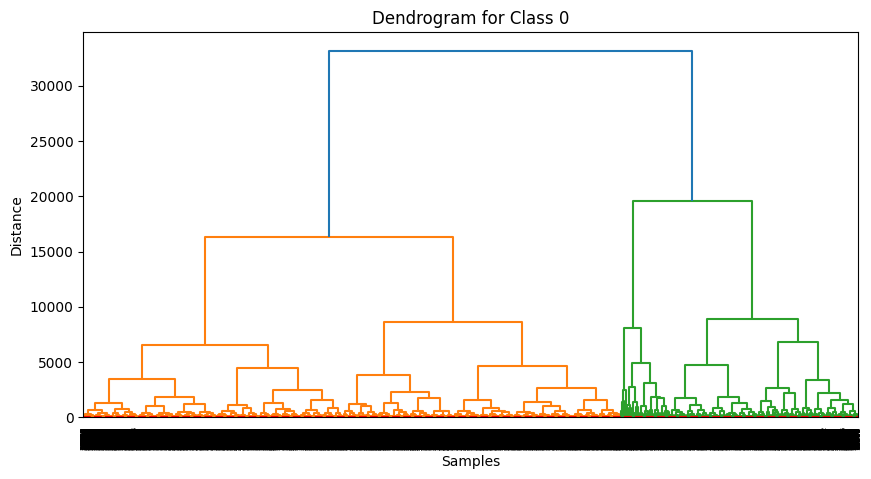

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_0, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 0")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_0, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 4


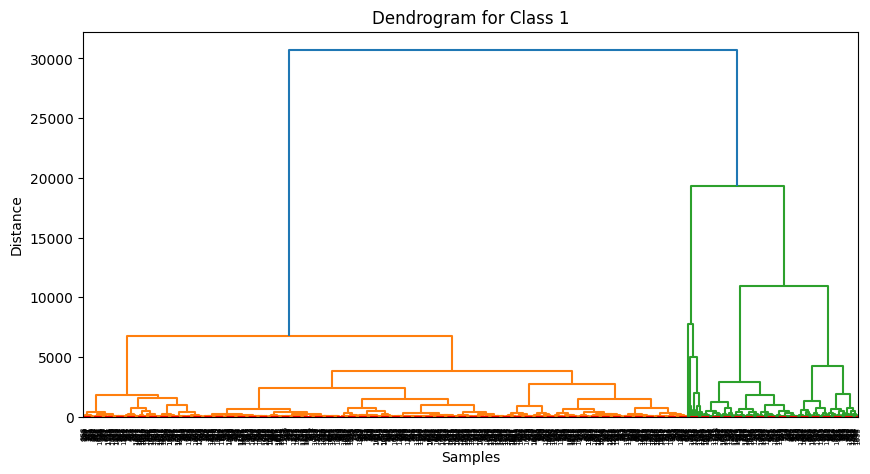

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_1, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 1")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_1, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 4


second method

In [ ]:
hc_0 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_0 = hc_0.fit_predict(X_0)

hc_1 = AgglomerativeClustering(n_clusters=2, linkage='ward')
sub_labels_1 = hc_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 6852 samples
Class 0 - Cluster 1: 15560 samples
Class 1 - Cluster 0: 269 samples
Class 1 - Cluster 1: 953 samples


Spectral Clustering

In [ ]:
def run_spectral_clustering(X_data, class_label):
    best_score = -1
    best_k = None
    best_labels = None

    # Search for the best number of clusters
    for k in range(2, 7):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',  # or 'rbf'
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels)
        print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    return best_labels, best_k, best_score

In [ ]:
# ---- Run Spectral Clustering with automatic k selection ----
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1, class_label=1)

Class 0 | n_clusters=2, Silhouette Score=0.5437
Class 0 | n_clusters=3, Silhouette Score=0.3796
Class 0 | n_clusters=4, Silhouette Score=0.3919
Class 0 | n_clusters=5, Silhouette Score=0.3835
Class 0 | n_clusters=6, Silhouette Score=0.3804
Best n_clusters for Class 0: 2 (Silhouette Score=0.5437)
Class 1 | n_clusters=2, Silhouette Score=0.6686
Class 1 | n_clusters=3, Silhouette Score=0.5090
Class 1 | n_clusters=4, Silhouette Score=0.3246
Class 1 | n_clusters=5, Silhouette Score=0.4022
Class 1 | n_clusters=6, Silhouette Score=0.3910
Best n_clusters for Class 1: 2 (Silhouette Score=0.6686)


In [ ]:
# Show cluster counts
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 18280 samples
Class 0 - Cluster 1: 4132 samples
Class 1 - Cluster 0: 937 samples
Class 1 - Cluster 1: 285 samples


reclustering

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# ---- STEP 1: Function for spectral clustering with silhouette selection ----
def run_spectral_clustering(X_data, class_label, k_range=(2,7)):
    best_score = -1
    best_k = None
    best_labels = None

    for k in range(*k_range):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)

        if len(np.unique(labels)) > 1:
            score = silhouette_score(X_data, labels)
            print(f"Class {class_label} | k={k}, Silhouette={score:.4f}")
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = labels
        else:
            print(f"Class {class_label} | k={k} → only one cluster found.")
    print(f"✅ Best k for Class {class_label}: {best_k} (Score={best_score:.4f})\n")
    return best_labels, best_k


# ---- STEP 2: Reclustering large clusters ----
def recluster_large_groups(X_data, labels, class_label, size_threshold=0.8, recluster_k=3):
    """
    Recluster the largest cluster if it holds more than 'size_threshold' proportion of samples.
    """
    counts = np.bincount(labels)
    total = len(labels)
    largest_cluster = np.argmax(counts)
    largest_ratio = counts[largest_cluster] / total

    print(f"Class {class_label} - Largest cluster = {largest_cluster} ({largest_ratio*100:.2f}% of data)")

    new_labels = labels.copy()
    offset = labels.max() + 1  # ensure new labels don't overlap

    if largest_ratio > size_threshold:
        # Extract subset to recluster
        idx_large = np.where(labels == largest_cluster)[0]
        X_large = X_data.iloc[idx_large]

        print(f"➡ Reclustering large cluster (size={len(X_large)}) into {recluster_k} subclusters...")
        sc = SpectralClustering(
            n_clusters=recluster_k,
            affinity='nearest_neighbors',
            assign_labels='kmeans',
            random_state=42
        )
        sub_labels = sc.fit_predict(X_large)
        new_labels[idx_large] = sub_labels + offset  # assign new unique labels

        print(f"✅ Reclustering done. Total clusters now: {new_labels.max()+1}")

    return new_labels


# ---- STEP 3: Combine process ----
def run_balanced_spectral(X_data, class_label):
    labels, best_k = run_spectral_clustering(X_data, class_label)
    new_labels = recluster_large_groups(X_data, labels, class_label)
    return new_labels


# ---- STEP 4: Apply to your data ----
# Example:
sub_labels_0 = run_balanced_spectral(X_0, class_label=0)
sub_labels_1 = run_balanced_spectral(X_1, class_label=1)


# ---- STEP 5: Show cluster distributions ----
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total: {total}")
    print(f"Balance Ratio: {counts.min()/counts.max():.3f}\n")

show_cluster_counts(sub_labels_0, 0)
show_cluster_counts(sub_labels_1, 1)

# ---- STEP 6: Further recluster Class 1’s dominant cluster ----
sub_labels_1_refined = recluster_large_groups(
    X_data=X_1,
    labels=sub_labels_1,
    class_label=1,
    size_threshold=0.7,  # recluster if >70% of samples
    recluster_k=3        # split large cluster into 3 subclusters
)

# ---- Show new cluster distribution after refinement ----
show_cluster_counts(sub_labels_1_refined, 1)


Class 0 | k=2, Silhouette=0.5437
Class 0 | k=3, Silhouette=0.3796
Class 0 | k=4, Silhouette=0.3919
Class 0 | k=5, Silhouette=0.3835
Class 0 | k=6, Silhouette=0.3804
✅ Best k for Class 0: 2 (Score=0.5437)

Class 0 - Largest cluster = 0 (81.56% of data)
➡ Reclustering large cluster (size=18280) into 3 subclusters...
✅ Reclustering done. Total clusters now: 5
Class 1 | k=2, Silhouette=0.6686
Class 1 | k=3, Silhouette=0.5090
Class 1 | k=4, Silhouette=0.3246
Class 1 | k=5, Silhouette=0.4022
Class 1 | k=6, Silhouette=0.3910
✅ Best k for Class 1: 2 (Score=0.6686)

Class 1 - Largest cluster = 0 (76.68% of data)

=== Cluster Distribution for Class 0 ===
Cluster 0: 0 samples (0.00%)
Cluster 1: 4132 samples (18.44%)
Cluster 2: 5521 samples (24.63%)
Cluster 3: 6279 samples (28.02%)
Cluster 4: 6480 samples (28.91%)
Total: 22412
Balance Ratio: 0.000


=== Cluster Distribution for Class 1 ===
Cluster 0: 937 samples (76.68%)
Cluster 1: 285 samples (23.32%)
Total: 1222
Balance Ratio: 0.304

Class 1 - L

In [ ]:
import numpy as np
import pandas as pd

# --- Step 7.1: Relabel clusters to remove gaps or empty ones ---
def relabel_clusters(labels):
    """Reindex cluster labels (remove gaps and empty clusters)."""
    unique_labels = sorted([l for l in np.unique(labels) if np.sum(labels == l) > 0])
    label_map = {old: new for new, old in enumerate(unique_labels)}
    new_labels = np.array([label_map[l] for l in labels])
    return new_labels

# Apply relabeling (including refined Class 1)
sub_labels_0 = relabel_clusters(sub_labels_0)
sub_labels_1_refined = relabel_clusters(sub_labels_1_refined)

# --- Step 7.2: Merge both class-wise clusters into one DataFrame ---
df_0 = X_0.copy()
df_0['Class'] = 0
df_0['Cluster_Label'] = sub_labels_0

df_1 = X_1.copy()
df_1['Class'] = 1
df_1['Cluster_Label'] = sub_labels_1_refined

# Combine both datasets
final_df = pd.concat([df_0, df_1], ignore_index=True)

# --- Step 7.3: Create continuous cluster numbering across both classes ---
# Example: class 0 clusters 0–4 → class 1 clusters start from 5
offset = final_df.loc[final_df['Class'] == 0, 'Cluster_Label'].max() + 1
final_df.loc[final_df['Class'] == 1, 'Cluster_Label'] += offset

# --- Step 7.4: Drop class column if you don't want it in the final CSV ---
final_df = final_df.drop(columns=['Class'])

# --- Step 7.5: Save to CSV ---
final_df.to_csv("Clustered_fraud_trans_dataset.csv", index=False)
print("✅ Clustered data saved successfully as 'Clustered_fraud_trans_dataset.csv'")

# --- Step 7.6: Optional summary ---
def show_cluster_counts(df):
    counts = df['Cluster_Label'].value_counts().sort_index()
    total = counts.sum()
    print("\n=== Final Cluster Distribution ===")
    for c, count in counts.items():
        pct = (count / total) * 100
        print(f"Cluster {c}: {count} samples ({pct:.2f}%)")
    print(f"Total Samples: {total}")
    print(f"Clusters: {len(counts)}\n")

show_cluster_counts(final_df)


✅ Clustered data saved successfully as 'Clustered_fraud_trans_dataset.csv'

=== Final Cluster Distribution ===
Cluster 0: 4132 samples (17.48%)
Cluster 1: 5521 samples (23.36%)
Cluster 2: 6279 samples (26.57%)
Cluster 3: 6480 samples (27.42%)
Cluster 4: 285 samples (1.21%)
Cluster 5: 401 samples (1.70%)
Cluster 6: 264 samples (1.12%)
Cluster 7: 272 samples (1.15%)
Total Samples: 23634
Clusters: 8



In [ ]:
clustered_df = pd.read_csv('Clustered_fraud_trans_dataset.csv')
print(clustered_df.head())

   Transaction Amount  Quantity  Customer Age  Account Age Days  \
0               42.32         1            40               282   
1              301.34         3            35               223   
2              340.32         5            29               360   
3               95.77         5            45               325   
4               77.45         5            42               116   

   Transaction Hour  Address Match  Customer Location Encoded  \
0                23              1                          1   
1                 0              1                          1   
2                 8              0                          5   
3                20              1                          1   
4                15              1                          1   

   Payment Method_PayPal  Payment Method_bank transfer  \
0                    1.0                           0.0   
1                    0.0                           0.0   
2                    0.0        

In [ ]:
clustered_df = pd.read_csv('Clustered_fraud_trans_dataset.csv')
clustered_df = clustered_df.rename(columns={'Cluster_Label': 'Is Fraudulent'})
clustered_df.to_csv('clustered_fraud_trans_with_target.csv', index=False)
print("DataFrame with 'Is Fraudulent' column saved as 'clustered_fraud_trans_with_target.csv'")
print(clustered_df.head())

DataFrame with 'Is Fraudulent' column saved as 'clustered_fraud_trans_with_target.csv'
   Transaction Amount  Quantity  Customer Age  Account Age Days  \
0               42.32         1            40               282   
1              301.34         3            35               223   
2              340.32         5            29               360   
3               95.77         5            45               325   
4               77.45         5            42               116   

   Transaction Hour  Address Match  Customer Location Encoded  \
0                23              1                          1   
1                 0              1                          1   
2                 8              0                          5   
3                20              1                          1   
4                15              1                          1   

   Payment Method_PayPal  Payment Method_bank transfer  \
0                    1.0                           0.0   
1  

MiniBatchKMeans

In [ ]:
n_clusters_0 = 2
mbk_0 = MiniBatchKMeans(
    n_clusters=n_clusters_0,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_0 = mbk_0.fit_predict(X_0)

n_clusters_1 = 3
mbk_1 = MiniBatchKMeans(
    n_clusters=n_clusters_1,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_1 = mbk_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 4882 samples
Class 0 - Cluster 1: 17530 samples
Class 1 - Cluster 0: 214 samples
Class 1 - Cluster 1: 969 samples
Class 1 - Cluster 2: 39 samples


reclustering

In [ ]:
def run_spectral_clustering(X_data, class_label=None, forced_k=None, k_range=(2, 7)):
    """
    Run spectral clustering trying k in range(k_range) (k_range end exclusive).
    If forced_k is provided and in tested ks, returns labels for forced_k.
    Returns: labels (np.array, indexed like X_data), chosen_k, score_for_chosen_k, scores_dict
    """
    all_scores = {}
    best_k = None
    best_score = -np.inf
    best_labels = None

    ks = list(range(k_range[0], k_range[1]))
    for k in ks:
        sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels) if len(np.unique(labels)) > 1 else -1
        all_scores[k] = score
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
        print(f"[{class_label}] k={k} -> silhouette={score:.4f}")

    # If forced_k requested and valid, recompute labels for forced_k
    if forced_k is not None:
        if forced_k not in all_scores:
            raise ValueError(f"forced_k {forced_k} not in tested ks {ks}")
        print(f"[{class_label}] Using forced_k={forced_k} (silhouette={all_scores[forced_k]:.4f})")
        sc = SpectralClustering(n_clusters=forced_k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        forced_labels = sc.fit_predict(X_data)
        return forced_labels, forced_k, all_scores[forced_k], all_scores

    return best_labels, best_k, best_score, all_scores


def initial_cluster_by_class(X, y, k_range=(2,7)):
    """
    Cluster data separately for each distinct class in y.
    Returns dict: class_label -> pd.Series(labels, index = X_class.index)
    Also returns dicts for chosen k and scores.
    """
    labels_by_class = {}
    best_k_by_class = {}
    score_by_class = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        labels, chosen_k, best_score, scores = run_spectral_clustering(X_cls, class_label=cls, k_range=k_range)
        labels_by_class[cls] = pd.Series(labels, index=X_cls.index)
        best_k_by_class[cls] = chosen_k
        score_by_class[cls] = best_score
    return labels_by_class, best_k_by_class, score_by_class


def get_cluster_counts(labels_by_class):
    """
    labels_by_class: dict from class_label -> pd.Series(labels, index=original indices)
    Returns nested dict: {class: {cluster_id: count, ...}, ...}
    """
    counts = {}
    for cls, ser in labels_by_class.items():
        vc = ser.value_counts().sort_index().to_dict()
        counts[cls] = vc
    return counts


def recluster_subset(X, y, labels_by_class, class_label, cluster_id, forced_k=None, k_range=(2,7)):
    """
    Recluster the subset corresponding to (class_label, cluster_id).
    Returns: sub_labels_series (pd.Series indexed same as subset), chosen_k, score
    Does NOT modify labels_by_class automatically; returns the new labels so caller can integrate.
    """
    # subset mask and X_subset
    mask = (y == class_label) & (labels_by_class[class_label] == cluster_id)
    X_subset = X.loc[mask]
    if X_subset.shape[0] < 2:
        raise ValueError("Subset has fewer than 2 samples; cannot recluster.")

    sub_labels, chosen_k, score, _ = run_spectral_clustering(X_subset, class_label=f"{class_label}-{cluster_id}",
                                                             forced_k=forced_k, k_range=k_range)
    return pd.Series(sub_labels, index=X_subset.index), chosen_k, score

def assemble_final_labels(X, y, labels_by_class, recluster_results=None):
    """
    Create a single Final_Cluster_Label column (int) for the full dataset.
    - labels_by_class: dict class -> pd.Series(original cluster labels)
    - recluster_results: dict with keys (class_label, cluster_id) -> pd.Series(sub_labels indexed like subset)
      If present, those samples will be assigned new sub-cluster ids (unique) instead of the original cluster id.
    Returns: final_labels (np.array aligned with X.index order), and mapping info
    """
    final_labels = np.full(len(X), -1, dtype=int)
    offset = 0
    mapping = {}

    # ensure series align to original indices
    for cls in sorted(labels_by_class.keys()):
        cls_series = labels_by_class[cls].reindex(X.loc[y==cls].index)  # ensure index order
        for orig_cluster in np.unique(cls_series):
            mask_idx = cls_series[cls_series == orig_cluster].index

            # if we reclustered this pair, use sublabels
            if recluster_results and (cls, orig_cluster) in recluster_results:
                sub_ser = recluster_results[(cls, orig_cluster)].reindex(mask_idx)
                # sublabels may be 0..(m-1) — make unique final ids: (offset + sublabel)
                unique_sub = np.unique(sub_ser.dropna())
                for sub in unique_sub:
                    sub_idx = mask_idx[sub_ser.loc[mask_idx] == sub]
                    final_labels[sub_idx] = offset
                    mapping[(cls, orig_cluster, sub)] = offset
                    offset += 1
            else:
                final_labels[mask_idx] = offset
                mapping[(cls, orig_cluster, None)] = offset
                offset += 1

    return final_labels, mapping


In [ ]:
sub_labels_0, best_k_0, best_score_0, scores_0 = run_spectral_clustering(X_0, class_label=0, forced_k=4)

[0] k=2 -> silhouette=0.5437
[0] k=3 -> silhouette=0.3796
[0] k=4 -> silhouette=0.3919
[0] k=5 -> silhouette=0.3835
[0] k=6 -> silhouette=0.3804
[0] Using forced_k=4 (silhouette=0.3919)


In [ ]:
sub_labels_1, best_k_1, best_score_1, scores_1 = run_spectral_clustering(X_1, class_label=1, forced_k=3)

[1] k=2 -> silhouette=0.6686
[1] k=3 -> silhouette=0.5090
[1] k=4 -> silhouette=0.3246
[1] k=5 -> silhouette=0.4022
[1] k=6 -> silhouette=0.3910
[1] Using forced_k=3 (silhouette=0.5090)


In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 6697 samples
Class 0 - Cluster 1: 7381 samples
Class 0 - Cluster 2: 1186 samples
Class 0 - Cluster 3: 7148 samples
Class 1 - Cluster 0: 700 samples
Class 1 - Cluster 1: 116 samples
Class 1 - Cluster 2: 406 samples


In [ ]:
recluster_results = {}
for cluster_id in np.unique(sub_labels_0):
    print(f"\nRe-clustering Class 0 - Cluster {cluster_id} into 3 sub-clusters")
    # select the subset of Class 0 corresponding to this cluster
    X_sub = X_0[sub_labels_0 == cluster_id]
    sub_sub_labels, k_val, s_val, _ = run_spectral_clustering(X_sub, class_label=f"0-{cluster_id}", forced_k=3)
    # store in recluster_results keyed by original cluster
    recluster_results[(0, cluster_id)] = pd.Series(sub_sub_labels, index=X_sub.index)

# print distribution
for key, ser in recluster_results.items():
    print(f"Class {key[0]} - Original Cluster {key[1]} -> Reclustered counts:")
    print(ser.value_counts().sort_index())

# Assemble final labels for the entire dataset
labels_by_class = {0: pd.Series(sub_labels_0, index=X_0.index),
                   1: pd.Series(sub_labels_1, index=X_1.index)}

final_labels, mapping = assemble_final_labels(X, y, labels_by_class, recluster_results=recluster_results)
df['Final_Cluster_Label'] = final_labels


Re-clustering Class 0 - Cluster 0 into 3 sub-clusters
[0-0] k=2 -> silhouette=0.3311
[0-0] k=3 -> silhouette=0.3759
[0-0] k=4 -> silhouette=0.3738
[0-0] k=5 -> silhouette=0.3518
[0-0] k=6 -> silhouette=0.3460
[0-0] Using forced_k=3 (silhouette=0.3759)

Re-clustering Class 0 - Cluster 1 into 3 sub-clusters
[0-1] k=2 -> silhouette=0.3697
[0-1] k=3 -> silhouette=0.3789
[0-1] k=4 -> silhouette=0.3753
[0-1] k=5 -> silhouette=0.3435
[0-1] k=6 -> silhouette=0.3165
[0-1] Using forced_k=3 (silhouette=0.3789)

Re-clustering Class 0 - Cluster 2 into 3 sub-clusters
[0-2] k=2 -> silhouette=0.4781
[0-2] k=3 -> silhouette=0.3715
[0-2] k=4 -> silhouette=0.3497
[0-2] k=5 -> silhouette=0.3581
[0-2] k=6 -> silhouette=0.3303
[0-2] Using forced_k=3 (silhouette=0.3715)

Re-clustering Class 0 - Cluster 3 into 3 sub-clusters
[0-3] k=2 -> silhouette=0.3712
[0-3] k=3 -> silhouette=0.3757
[0-3] k=4 -> silhouette=0.3777
[0-3] k=5 -> silhouette=0.3483
[0-3] k=6 -> silhouette=0.3052
[0-3] Using forced_k=3 (silhoue

In [ ]:
# Step 5: Check final distribution
print("\nFinal cluster distribution across all classes:")
print(df['Final_Cluster_Label'].value_counts().sort_index())


Final cluster distribution across all classes:
Final_Cluster_Label
0     2599
1     2218
2     1880
3     2449
4     2352
5     2580
6      369
7      409
8      408
9     2425
10    2411
11    2312
12     700
13     116
14     406
Name: count, dtype: int64
